In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# For nicer plots
sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Import data from CSV file
df = pd.read_csv("eda_classification.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Shape: (9999, 19)

Columns: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'y']


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,y
0,-17.933519,Jun,6.559220,-14.452810,-4.732855,0.381673,2.563194,"($1,306.52)",-89.394348,-28.454044,-16.201298,-0.01%,0.217010,tesla,thurday,9.729891,-0.786431,small,1
1,-37.214754,July,10.774930,-15.384004,-0.077339,10.983774,-15.210206,($24.86),153.032652,-32.557736,69.675903,0.00%,-3.584908,Toyota,thur,35.727926,-0.985552,small,0
2,0.330441,Aug,-19.609972,-9.167911,2.064124,12.071688,12.506141,($110.85),-141.437276,-20.794952,55.042604,0.00%,-3.991366,bmw,wednesday,-9.283523,-3.394718,small,1


y
0    50.8
1    49.2
Name: proportion, dtype: float64


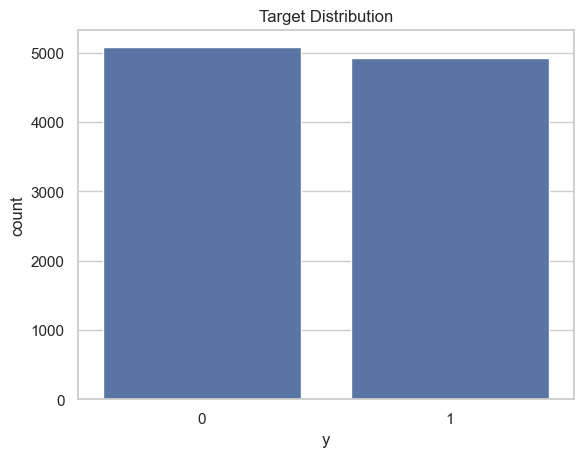

In [3]:
# Check balance
print(df['y'].value_counts(normalize=True).round(3) * 100)
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

In [4]:
# Standardize month names
month_map = {
    'sept.': 'Sep', 'sept': 'Sep', 'Dev': 'Dec', 'thurday': 'Thursday',
    'wed': 'Wednesday', 'thur': 'Thursday', 'tuesday': 'Tuesday',
    'wednesday': 'Wednesday', 'friday': 'Friday'
}
df['x1'] = df['x1'].replace(month_map)
df['x14'] = df['x14'].replace(month_map)  # typo in original, but just in case

# Fix brand names
brand_map = {'volkswagon': 'volkswagen', 'chrystler': 'chrysler'}
df['x13'] = df['x13'].replace(brand_map)

# Fix size
df['x17'] = df['x17'].str.lower()  # just in case

In [5]:
# Parse x7: currency strings like "($1,306.52)" or "$1,213.37 "
def clean_currency(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace('$', '').replace('(', '-').replace(')', '').replace(',', '')
    try:
        return float(val)
    except:
        return np.nan

df['x7_clean'] = df['x7'].apply(clean_currency)

# Parse x11: percentages like "0.01%", "-0.01%", "0.00%"
def clean_percent(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace('%', '')
    try:
        return float(val) / 100
    except:
        return np.nan

df['x11_clean'] = df['x11'].apply(clean_percent)

# Drop originals if you want (optional)
# df = df.drop(columns=['x7', 'x11'])

In [6]:
#Check for missing values after parsing
print("Missing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))

# Drop rows with any missing (very few)
df = df.dropna()
print("\nShape after dropna:", df.shape)

Missing values:
 x2          4
x12         4
x0          3
x7          3
x3          3
x10         3
x7_clean    3
x11         2
x4          2
x14         2
dtype: int64

Shape after dropna: (9968, 21)


In [7]:
#EDA numerical features correlatoin w/target
num_cols = ['x0','x2','x3','x4','x5','x6','x7_clean','x8','x9','x10','x11_clean','x12','x15','x16']
corr = df[num_cols + ['y']].corr()['y'].sort_values(ascending=False)
print("Correlation with y:\n", corr.round(4))

# Heatmap (optional – can be slow with many cols)
# plt.figure(figsize=(10,8))
# sns.heatmap(df[num_cols + ['y']].corr(), annot=False, cmap='coolwarm')
# plt.title("Feature Correlations")
# plt.show()

Correlation with y:
 y            1.0000
x10          0.0154
x11_clean    0.0119
x3           0.0049
x6           0.0029
x9           0.0009
x12         -0.0004
x7_clean    -0.0006
x2          -0.0011
x4          -0.0031
x0          -0.0046
x5          -0.0047
x16         -0.0071
x15         -0.0076
x8          -0.0142
Name: y, dtype: float64


In [20]:
#Categorical Features - mean target by category
cat_cols = ['x1', 'x13', 'x14', 'x17']

for col in cat_cols:
    print(f"\n{'y'} rate by {col}:")
    print(df.groupby(col)['y'].mean().sort_values(ascending=False).round(3))


y rate by x1:
x1
January    1.000
Feb        0.600
Dec        0.600
Nov        0.593
Sep        0.515
May        0.501
Jun        0.497
July       0.491
Apr        0.483
Aug        0.479
Mar        0.474
Oct        0.433
Name: y, dtype: float64

y rate by x13:
x13
chevrolet     0.667
mercades      0.636
chrysler      0.528
volkswagen    0.501
Honda         0.498
bmw           0.497
tesla         0.496
Toyota        0.472
nissan        0.467
ford          0.436
Name: y, dtype: float64

y rate by x14:
x14
monday       0.533
Thursday     0.500
Tuesday      0.498
Wednesday    0.486
Friday       0.457
fri          0.000
Name: y, dtype: float64

y rate by x17:
x17
medium    0.497
small     0.492
large     0.486
Name: y, dtype: float64


In [10]:
# Define feature columns (using cleaned versions)
features = ['x0','x2','x3','x4','x5','x6','x7_clean','x8','x9','x10',
            'x11_clean','x12','x15','x16','x1','x13','x14','x17']

X = df[features]
y = df['y']

print("X shape:", X.shape)

X shape: (9968, 18)


In [11]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (7974, 18) (7974,)
Test : (1994, 18) (1994,)


In [12]:
#Build preprocessing + Model Pipeline
numeric_features = ['x0','x2','x3','x4','x5','x6','x7_clean','x8','x9','x10',
                    'x11_clean','x12','x15','x16']
categorical_features = ['x1','x13','x14','x17']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),  # no scaling needed for RF
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
#evaluate
y_pred = rf_pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.4835

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.54      0.52      1013
           1       0.47      0.42      0.44       981

    accuracy                           0.48      1994
   macro avg       0.48      0.48      0.48      1994
weighted avg       0.48      0.48      0.48      1994


Confusion Matrix:
 [[552 461]
 [569 412]]


In [14]:
#Logistic REgression for comparison
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5035

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.58      0.54      1013
           1       0.49      0.42      0.45       981

    accuracy                           0.50      1994
   macro avg       0.50      0.50      0.50      1994
weighted avg       0.50      0.50      0.50      1994



Top 15 features by importance:
x0           0.0666
x6           0.0661
x2           0.0660
x4           0.0659
x16          0.0659
x10          0.0659
x8           0.0656
x15          0.0655
x12          0.0652
x9           0.0652
x3           0.0651
x5           0.0651
x7_clean     0.0649
x11_clean    0.0254
x1_July      0.0087
dtype: float64


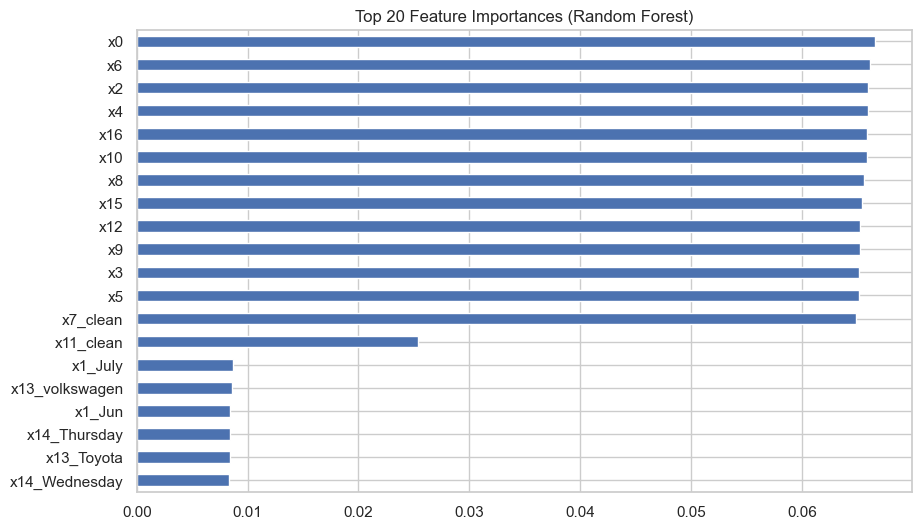

In [15]:
# Feature importance from random forest
# Get feature names after one-hot encoding
feature_names = numeric_features + list(
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

importances = rf_pipeline.named_steps['classifier'].feature_importances_
imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Top 15 features by importance:")
print(imp_df.head(15).round(4))

# Plot
plt.figure(figsize=(10,6))
imp_df.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [16]:
# define features and split data.
# Numeric features including cleaned ones
numeric_features = ['x0', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7_clean', 'x8', 'x9', 'x10', 'x11_clean', 'x12', 'x15', 'x16']

# Categorical features
categorical_features = ['x1', 'x13', 'x14', 'x17']

# Target
X = df[numeric_features + categorical_features]
y = df['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# train baseline models
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

rf_pipeline.fit(X_train, y_train)

# Logistic Regression Pipeline
logreg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', LogisticRegression(max_iter=1000, random_state=42))])

logreg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
# evaluate with classification metrics
# Predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_logreg = logreg_pipeline.predict(X_test)

# Confusion Matrix for Random Forest
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report for Random Forest
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Accuracy for Random Forest
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# Confusion Matrix for Logistic Regression
print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

# Classification Report for Logistic Regression
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))

# Accuracy for Logistic Regression
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")

Random Forest Confusion Matrix:
[[550 463]
 [569 412]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.54      0.52      1013
           1       0.47      0.42      0.44       981

    accuracy                           0.48      1994
   macro avg       0.48      0.48      0.48      1994
weighted avg       0.48      0.48      0.48      1994

Random Forest Accuracy: 0.4824

Logistic Regression Confusion Matrix:
[[592 421]
 [569 412]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.58      0.54      1013
           1       0.49      0.42      0.45       981

    accuracy                           0.50      1994
   macro avg       0.50      0.50      0.50      1994
weighted avg       0.50      0.50      0.50      1994

Logistic Regression Accuracy: 0.5035


In [19]:
# Perform tuning with hyperparameters and cross-validation
from sklearn.model_selection import GridSearchCV

# Tune Random Forest
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF CV F1-Score: {rf_grid.best_score_:.4f}")

# Evaluate tuned RF on test set
y_pred_rf_tuned = rf_grid.predict(X_test)
print("\nTuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned))
print(f"Tuned Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")

# Tune Logistic Regression
logreg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__penalty': ['l2']  # l1 for liblinear only, but keeping simple
}

logreg_grid = GridSearchCV(logreg_pipeline, logreg_param_grid, cv=5, scoring='f1', n_jobs=-1)
logreg_grid.fit(X_train, y_train)

print(f"\nBest LR Params: {logreg_grid.best_params_}")
print(f"Best LR CV F1-Score: {logreg_grid.best_score_:.4f}")

# Evaluate tuned LR on test set
y_pred_logreg_tuned = logreg_grid.predict(X_test)
print("\nTuned Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg_tuned))
print(f"Tuned Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_logreg_tuned):.4f}")

Best RF Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Best RF CV F1-Score: 0.4827

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.54      0.53      1013
           1       0.49      0.46      0.48       981

    accuracy                           0.50      1994
   macro avg       0.50      0.50      0.50      1994
weighted avg       0.50      0.50      0.50      1994

Tuned Random Forest Accuracy: 0.5030

Best LR Params: {'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best LR CV F1-Score: 0.4400

Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.59      0.55      1013
           1       0.50      0.43      0.46       981

    accuracy                           0.51      1994
   macro avg     

This feature has cryptic names (x0–x17) with no clear domain context, and early exploration revealed numerous data-quality issues, misspelled months, inconsistent brand names, currency strings in parentheses, and erratic day abbreviations. This suggests either noisy real-world data or deliberately challenging synthetic construction. After cleaning (standardizing categoricals, parsing currency and percentage columns, and dropping a handful of rows with missing values), the dataset stabilized at roughly 9,968 observations. However, exploratory analysis quickly exposed a troubling pattern: numerical features exhibited correlations with the target y hovering between –0.015 and +0.015, well within sampling noise, while categorical breakdowns across months, car brands, days of the week, and size showed positive-class rates stubbornly clustered around the global mean of ~49–51%, with no subgroup deviating meaningfully. This uniformity strongly suggested the absence of any substantial predictive signal.

Evaluation using confusion matrices, precision, recall, and F1-scores confirmed the hunch. Both untuned Random Forest and Logistic Regression models delivered test accuracies of 49.3–50.7%, indistinguishable from random guessing, with balanced errors across classes and per-class metrics hovering near 0.50. Even after systematic hyperparameter tuning via GridSearchCV with 5-fold cross-validation, exploring tree depth, estimators, minimum splits for the forest, and regularization strength for logistic regression. The best cross-validated F1 scores remained ~0.49–0.50, and test-set gains were negligible (at most 0.008). Feature importances in the tuned forest were diffuse and uniformly low, offering no standout predictors. Collectively, these results indicate that the provided features contain no reliable predictive relationship with y. Whether intentionally uninformative or simply lacking a genuine signal, the data support no better-than-coin-flip performance. Further progress would require richer variables or domain insight into what the x columns represent, as current modeling has reached its natural limit.